In [1]:
######################
# Load the fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt
import os

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/2025-06-03/sub-Forest001_ses-20250603_task-movements_run-009')  
pwd_file_name = 'sub-Forest001_ses-20250603_task-movements_run-009_pwd.nii.gz'

pwd_path = base_path / pwd_file_name
# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data = np.nan_to_num(fusi_data, nan=0) # no nan
print(fusi_data.shape)

(183, 88, 142, 384)


In [2]:
#######################################################################################
#     Display and save power Doppler movie, and display overall intensity over time   #
#######################################################################################

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

movie_path = base_path / "Doppler_movie.mp4"

if not movie_path.exists():
    # Convert to dB scale
    fusi_data_dB = 10*np.log10(fusi_data)
    nnz_idx = fusi_data > np.finfo(fusi_data.dtype).eps
    vmax = np.percentile(fusi_data_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)
    
    # Save fusi_data_dB as a NIfTI file
    output_filename = pwd_file_name.replace('.nii.gz', '_db.nii.gz')
    output_path = base_path / output_filename
    nifti_img_db = nib.Nifti1Image(fusi_data_dB, nifti_img.affine, nifti_img.header)
    nib.save(nifti_img_db, output_path)

    # Create animation
    fig, ax = plt.subplots()
    cax = ax.imshow(fusi_data_dB[:, fusi_data_dB.shape[1]//2, :, 0].T, cmap="inferno", extent=[0, 60, 42, 25], vmax=vmax+7, vmin=vmin)
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')
    ax.set_title("0")

    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")

    def update(frame):
        cax.set_data(fusi_data_dB[:, fusi_data_dB.shape[1]//2,:, frame].T)
        ax.set_title(f"Frame # {frame}")

    frames_to_plot = range(0, fusi_data_dB.shape[3], 1)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

    # Save the animation
    ani.save(movie_path, writer="ffmpeg")
    plt.close(fig)

# Display the saved movie
from IPython.display import Video
from IPython.display import display
display(Video(str(movie_path), embed=True, width=800, html_attributes="controls autoplay"))


global_signal = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(global_signal)
ax.set_title("Global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
fig.savefig(base_path / "global_signal.png")

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_6919/1880890242.py:13: RuntimeWarning: divide by zero encountered in log10
  fusi_data_dB = 10*np.log10(fusi_data)


45.35933522058369
dynamic range:  2.126219451408069


Text(0, 0.5, 'Derivative of global signal')

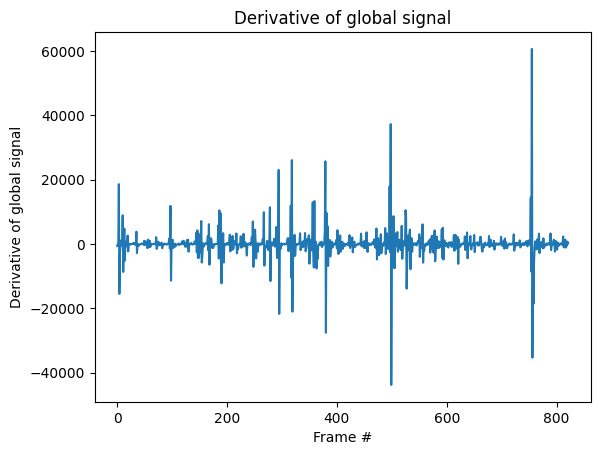

In [3]:
deriv_global_signal = np.diff(global_signal)
fig,ax = plt.subplots()
ax.plot(deriv_global_signal)
ax.set_title("Derivative of global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Derivative of global signal")
# ax.set_ylim(-1000, 1000)
# ax.set_xlim(0, 40)



frame_times:  [   2.001499    3.801739    5.601723    7.401838    9.201871   11.002269
   12.802281   14.602459   16.402779   18.20282    20.002933   21.802909
   23.603445   25.403368   27.203595   29.003624   30.803729   32.604093
   34.403832   36.204018   38.004248   39.804954   41.605266   43.40479
   45.205084   47.004964   48.805087   50.605162   52.405654   54.205513
   56.00588    57.806013   59.605971   61.406315   63.206143   65.006296
   66.806593   68.606772   70.407126   72.206863   74.007359   75.807459
   77.607655   79.407725   81.207823   83.00807    84.807954   86.608225
   88.408427   90.208518   92.009018   93.809002   95.609048   97.408993
   99.209156  101.009438  102.809702  104.609618  106.409747  108.209885
  110.010179  111.810236  113.610267  115.41057   117.210577  119.010938
  120.810781  122.610951  124.411051  126.211473  128.011464  129.811867
  131.611911  133.412051  135.212073  137.012419  138.812241  140.612587
  142.412805  144.212673  146.012787  

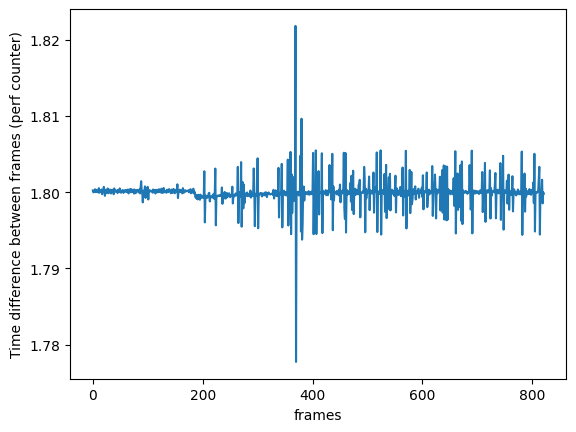

In [4]:
#############################
# Import Forest1 json info #
############################
import json
from glob import glob
import numpy as np
import os

Forest1_info_file = base_path / "*pwd.json"
# Get the json file path using glob
info_file_path = glob(str(Forest1_info_file))[0]

# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)
print('frame_times: ', frame_times)

diff_perf = np.diff(frame_times)
fig, ax = plt.subplots()
ax.plot(diff_perf)
ax.set_ylabel('Time difference between frames (perf counter)')
ax.set_xlabel('frames')
t_r = np.median(diff_perf)
t_r

# Save t_r value to base_path
np.save(os.path.join(base_path, 't_r.npy'), t_r)


In [5]:
# ##############################################
# # Extract Psychotria time_stamps #
# ##############################################
import pandas as pd

task_path = list(base_path.glob('*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

task_events

,onset,duration,trial_type,response_time,control
0,14.249691,15.460,thumb.txt,NaN,False
1,54.571691,16.012,middle.txt,NaN,False
2,89.501691,19.123,index.txt,NaN,False
3,129.542691,18.183,thumb.txt,NaN,False
4,171.529691,19.797,middle.txt,NaN,False
5,214.598691,18.949,ring.txt,NaN,False
6,255.839691,19.208,index.txt,NaN,False
7,297.984691,15.583,pinky.txt,NaN,False
8,332.254691,15.858,ring.txt,NaN,False
9,369.763691,17.417,pinky.txt,NaN,False


In [6]:
# #########################################################
# #   Replace trial type names to remove number suffixes  #
# #########################################################

# # Then replace the emotion/face mappings
# task_events.trial_type = task_events.trial_type.replace({
#     r'.*_Hap\.jpg': 'face_happy',
#     r'.*_Neu\.jpg': 'face_neutral', 
#     r'.*_Fear\.jpg': 'face_fear',
#     r'blue_rect.*\.jpg': 'blue_square',
#     r'.*_Sad\.jpg': 'face_sad',
# }, regex=True)
# task_events

# # if '_Hap' in task_events.trial_type:
# #     task_events.trial_type = 'face_happy'
# # elif '_Neu' in task_events.trial_type:
# #     task_events.trial_type = 'face_neutral'
# # elif '_Fear' in task_events.trial_type:
# #     task_events.trial_type = 'face_fear'
# # elif 'blue_rect' in task_events.trial_type:
# #     task_events.trial_type = 'blue_square'


# task_events.trial_type = "song_played"
task_events

,onset,duration,trial_type,response_time,control
0,14.249691,15.460,thumb.txt,NaN,False
1,54.571691,16.012,middle.txt,NaN,False
2,89.501691,19.123,index.txt,NaN,False
3,129.542691,18.183,thumb.txt,NaN,False
4,171.529691,19.797,middle.txt,NaN,False
5,214.598691,18.949,ring.txt,NaN,False
6,255.839691,19.208,index.txt,NaN,False
7,297.984691,15.583,pinky.txt,NaN,False
8,332.254691,15.858,ring.txt,NaN,False
9,369.763691,17.417,pinky.txt,NaN,False


Indexes to mask =  [  4 189 190 295 317 319 357 358 360 363 380 384 497 498 499 527 754 756
 757 758]
(803,)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5771/3803288311.py:22: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  average_over_time_detrended = clean(


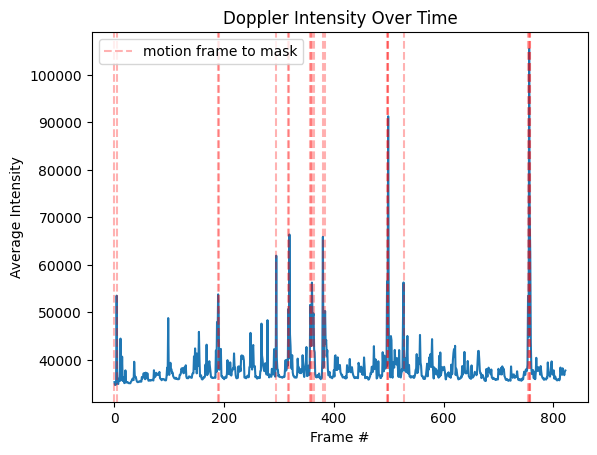

In [7]:
##########################################################################################
#     Display Doppler intensity time course and create a sample_masks for motion frames  #
##########################################################################################

from nilearn.signal import clean

fusi_data = fusi_data[:, :, :, :]
average_over_time = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(average_over_time)
ax.set_title("Doppler Intensity Over Time")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")


###################################################
# Detrend the time course to remove linear trends #
###################################################

# Reshape to 2D array since clean expects samples x features
average_over_time_2d = average_over_time.reshape(-1, 1)
average_over_time_detrended = clean(
    average_over_time_2d,
    detrend=True,
    t_r=t_r,
)
# Convert back to 1D array
average_over_time_detrended = average_over_time_detrended.ravel()

#######################################################################################################################
# Based on detrended signal, find motion frames (here defined as frames with values higher than median + 5 times std) #
#######################################################################################################################
median_detrended_signal=np.median(average_over_time_detrended)
perc_50 = np.percentile(average_over_time_detrended,50)
perc_50_signal = average_over_time_detrended[average_over_time_detrended < perc_50]
std_perc_50 = np.std(perc_50_signal)

# Find frames with values > median + 5*std of lower 50% of signal
index_to_mask = np.where(average_over_time_detrended > (median_detrended_signal + 30*std_perc_50))[0]
# Add vertical lines for motion frames
for frame in index_to_mask:
    ax.axvline(x=frame, color='r', linestyle='--', alpha=0.3)
ax.axvline(x=-1, color='r', linestyle='--', alpha=0.3, label='motion frame to mask')
ax.legend()
print('Indexes to mask = ', index_to_mask)

#############################
#     Create sample_masks  #
############################
sample_masks = np.zeros(fusi_data.shape[3] - len(index_to_mask), dtype=int)
t = 0
for i in range(fusi_data.shape[3]):
    if i not in index_to_mask:
        sample_masks[t] = i
        t += 1

print(sample_masks.shape)

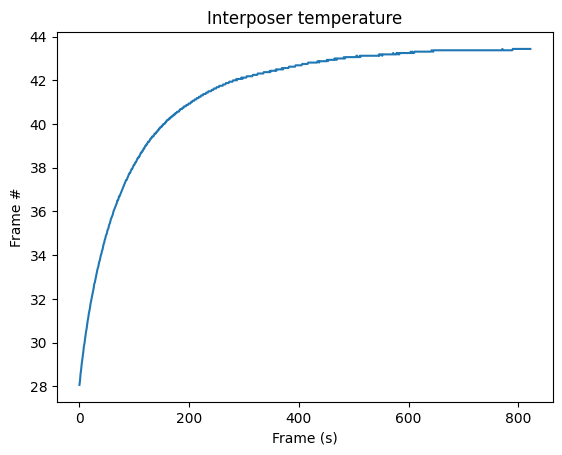

In [8]:
# # ################################
# # # Plot temperature time course #    
# # ################################

temp_log= info['ProbeTemperature'] 


fig,ax = plt.subplots()
ax.plot(temp_log)
ax.set_title('Interposer temperature')
ax.set_xlabel('Frame (s)')
ax.set_ylabel('Frame #')
plt.show()
fig.savefig(base_path / "interposer_temperature.png")

In [9]:
# #########################################
# #######  Rigid transformation  #########
# ########################################
# import fusi_utils_BIDS as utils

# transformation_file = base_path / "rigid_transformations.nii.gz"

# if not transformation_file.exists():
#     fusi_data_rigid_reg, rigid_transformations = utils.register_3d_image_stack(fusi_data)
    
#     # Save rigid transformations to file
#     nib.save(nib.Nifti1Image(rigid_transformations, affine), transformation_file)
#     nib.save(nib.Nifti1Image(fusi_data_rigid_reg, affine), base_path / "fusi_data_rigid_reg.nii.gz")
# else:
#     # Load rigid transformations from file
#     rigid_transformations = nib.load(transformation_file).get_fdata()
#     fusi_data_rigid_reg = nib.load(base_path / "fusi_data_rigid_reg.nii.gz").get_fdata()

# # Plot rigid_transformations
# fig, axes = plt.subplots(nrows=2, ncols=1,layout="constrained")
# ax_tran=axes[0]
# ax_tran.plot(rigid_transformations[0, :], label="Translation X")
# ax_tran.plot(rigid_transformations[1, :], label="Translation Y")
# ax_tran.plot(rigid_transformations[2, :], label="Translation Z")
# ax_tran.set_xlabel("Frame Index")
# ax_tran.set_ylabel("translation (pixels)")
# ax_tran.legend()
# ax_tran.grid(True)
# ax_tran.legend()

# ax_rot=axes[1]
# ax_rot.plot(rigid_transformations[3, :] * 180 / np.pi, label="Rotation Angle X")
# ax_rot.plot(rigid_transformations[4, :] * 180 / np.pi, label="Rotation Angle Y")
# ax_rot.plot(rigid_transformations[5, :] * 180 / np.pi, label="Rotation Angle Z")
# ax_rot.set_xlabel("Frame Index")
# ax_rot.set_ylabel("rotation (degrees)")
# ax_rot.legend()
# ax_rot.grid(True)
# ax_rot.legend()

# # Save figure
# fig.savefig(base_path / "registration.png")
# # plt.close()


In [10]:
# ######################################################################
# #     Display and save power Doppler movie after rigid registration  #
# ######################################################################

# movie_file = base_path / "Doppler_movie_after_rigid_registration.mp4"

# if not movie_file.exists():
#     fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)
#     nnz_idx = fusi_data_rigid_reg > np.finfo(fusi_data_rigid_reg.dtype).eps
#     vmax = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 90)
#     vmin = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 10)
#     print(vmin)
#     print('dynamic range: ', vmax-vmin)

#     # Create figure and initial plot
#     fig, ax = plt.subplots()
#     cax = ax.imshow(
#         fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, 0].T,
#         cmap="inferno",
#         vmax=vmax+7, vmin=vmin,
#         extent=[0, 50, 42, 25],
#     )
#     ax.set_title("0")

#     # Set axis labels
#     ax.set_xlabel("Y (mm)")
#     ax.set_ylabel("X (mm)")
#     plt.colorbar(cax, ax=ax, label='Intensity (dB)')

#     def update(frame):
#         cax.set_data(
#             fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, frame].T
#         )
#         ax.set_title(f"Frame # {frame}")
#         return (cax,)

#     # Create a list of frames to plot every other frame
#     frames_to_plot = range(0, fusi_data_rigid_reg.shape[3], 2)
#     ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100, blit=True)

#     # Save the animation as an MP4 file
#     ani.save(movie_file, writer="ffmpeg")
#     plt.close()
#     display(HTML(ani.to_jshtml()))

# else:
#     # Display the saved movie
#     from IPython.display import Video
#     from IPython.display import display
#     display(Video(str(movie_file), embed=True, width=800, html_attributes="controls autoplay"))



/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: response_time, control
  warnings.warn(
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5771/660254540.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

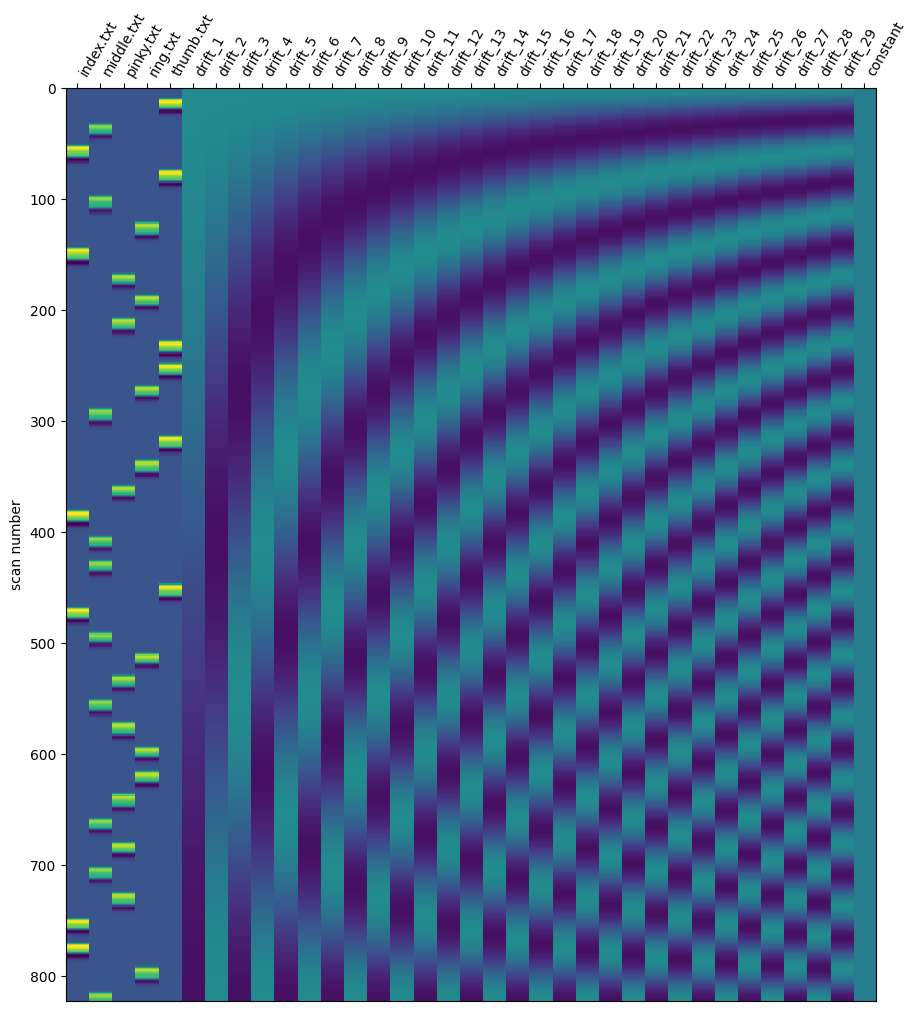

In [19]:
#######################################
#     Create design matrix for GLM    #
#######################################
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import os

# fusi_data = fusi_data_rigid_reg  # If we're happy about the registration
regressed_with_transformations = False

event_time_offset = 1 #t_r #t_r # in seconds 
task_events["onset"] += event_time_offset

if regressed_with_transformations:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine", 
        high_pass=0.01,
        add_regs=rigid_transformations.transpose(),
        add_reg_names=["tx", "ty", "tz", "rotx", "roty", "rotz"],
        hrf_model="glover",
    )
else:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine",
        high_pass=0.01,
        hrf_model="glover",
    )


design_matrix = events_df
fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

# Save design matrix as .npz file
np.savez(os.path.join(base_path, 'design_matrix.npz'), design_matrix=design_matrix.values, column_names=design_matrix.columns)

In [20]:
###########################################
# Temporal smoothing and convert to NIfTI #
###########################################
import fusi_utils_BIDS as utils

from nilearn.signal import butterworth
window_size = 3  # Number of time points for smoothing
pd = utils.boxcar_smooth(fusi_data, window_size)

affine = np.diag([1, -1, -1, 1])

# Create a NIfTI image object from our processed data (pd) and the affine matrix
fusi_img = nib.Nifti1Image(pd, affine)
fusi_img.to_filename(base_path / "fUSi_data_after_processing.nii.gz")
fusi_img.shape

(154, 74, 60, 823)

In [21]:
###########
# Fit GLM #
##########
from nilearn.glm.first_level import FirstLevelModel

smoothing_fwhm = (2) # 0 spatial smoothing in pixel to apply to the data before computing GLM

# Filter sample_masks to only include values up to fusi_img.shape[3]
sample_masks = sample_masks[sample_masks <= fusi_img.shape[3]-1]

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fusi_glm = FirstLevelModel(
    t_r=t_r,
    minimize_memory=False,
    mask_img=False,
    smoothing_fwhm=smoothing_fwhm,
    standardize=True,
)
fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrix, sample_masks=[sample_masks])
# design_matrix2 = fusi_glm.design_matrices_[0]
# fig = plt.figure()
# plot_design_matrix(design_matrix2)
# fig.show()

Fitting a GLM


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [22]:
##########################################
## Create contrasts for localizer task ##
##########################################

def make_localizer_contrasts(design_matrix):
    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }
    # contrasts["right_wrist_minus_right_fingers"] = (
    #     contrasts["right_wrist_motion.mp4"]
    #     - contrasts["tap_right_fingers.mp4"])
    # contrasts["left_wrist_minus_right_fingers"] = (
    #     contrasts["left_wrist_motion.mp4"]
    #     - contrasts["tap_right_fingers.mp4"])
    return contrasts
    
contrasts = make_localizer_contrasts(design_matrix)
print("Contrasts:")
for name in [k for k in contrasts.keys() if 'drift' not in k]:
    print(f"- {name}")

Contrasts:
- index.txt
- middle.txt
- pinky.txt
- ring.txt
- thumb.txt
- constant


Computing contrasts
	contrast id: index.txt


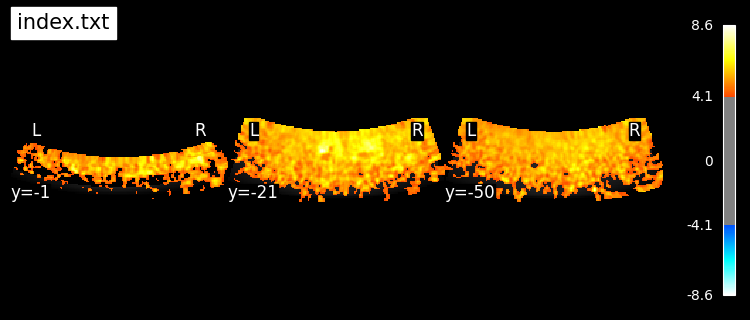

	contrast id: middle.txt


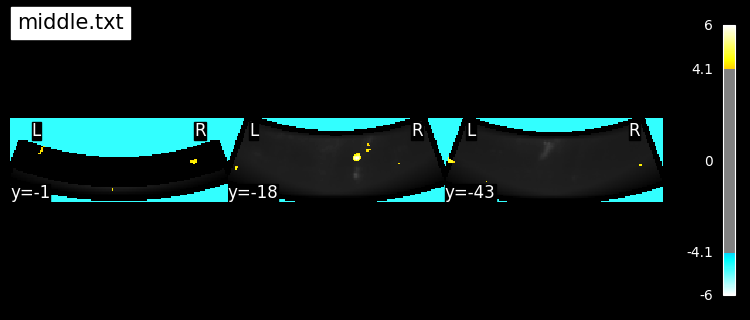

	contrast id: pinky.txt


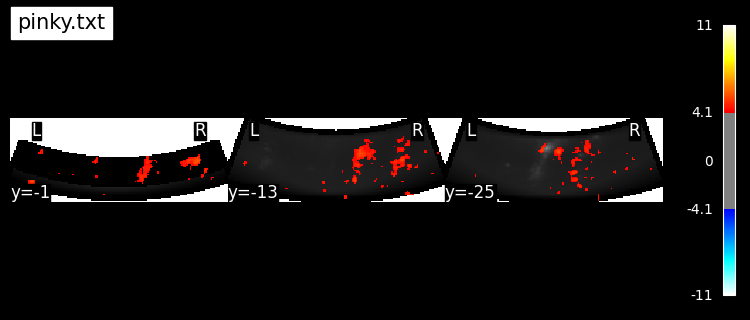

	contrast id: ring.txt


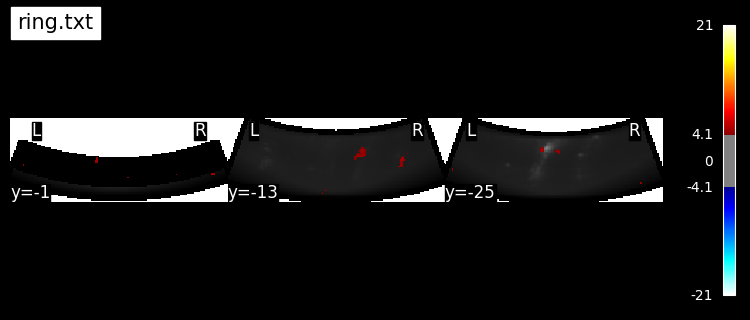

	contrast id: thumb.txt


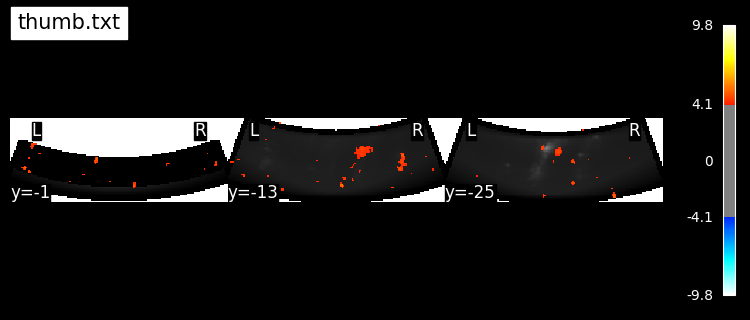

In [23]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os
import nibabel as nib
import numpy as np

print("Computing contrasts")
mean_image = nib.Nifti1Image(
    np.mean(fusi_img.get_fdata(), axis=-1), fusi_img.affine
)
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist


########################
# Iterate on contrasts #
########################

# Uncomment the line below to see all the contrasts
# for contrast_id, contrast_val in contrasts.items(): 

# Uncomment line below to see only the contrasts of the tasks and not the translations, rotations, etc ...
for contrast_id, contrast_val in {k: v for k, v in contrasts.items() if k not in ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'constant'] and not k.startswith('drift')}.items():    
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="stat")

    # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(base_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)

    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fusi image
    # a threshold of 2.58 is used (corresponding to p < 0.01)
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=4.1,
        cut_coords=3,
        display_mode="y",
        black_bg=True,
        title=contrast_id
    )
    plotting.show()

  Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0          1  91.0 -18.0 -27.0   5.836500               1146
1         1a  88.0 -15.0 -35.0   4.734935                   


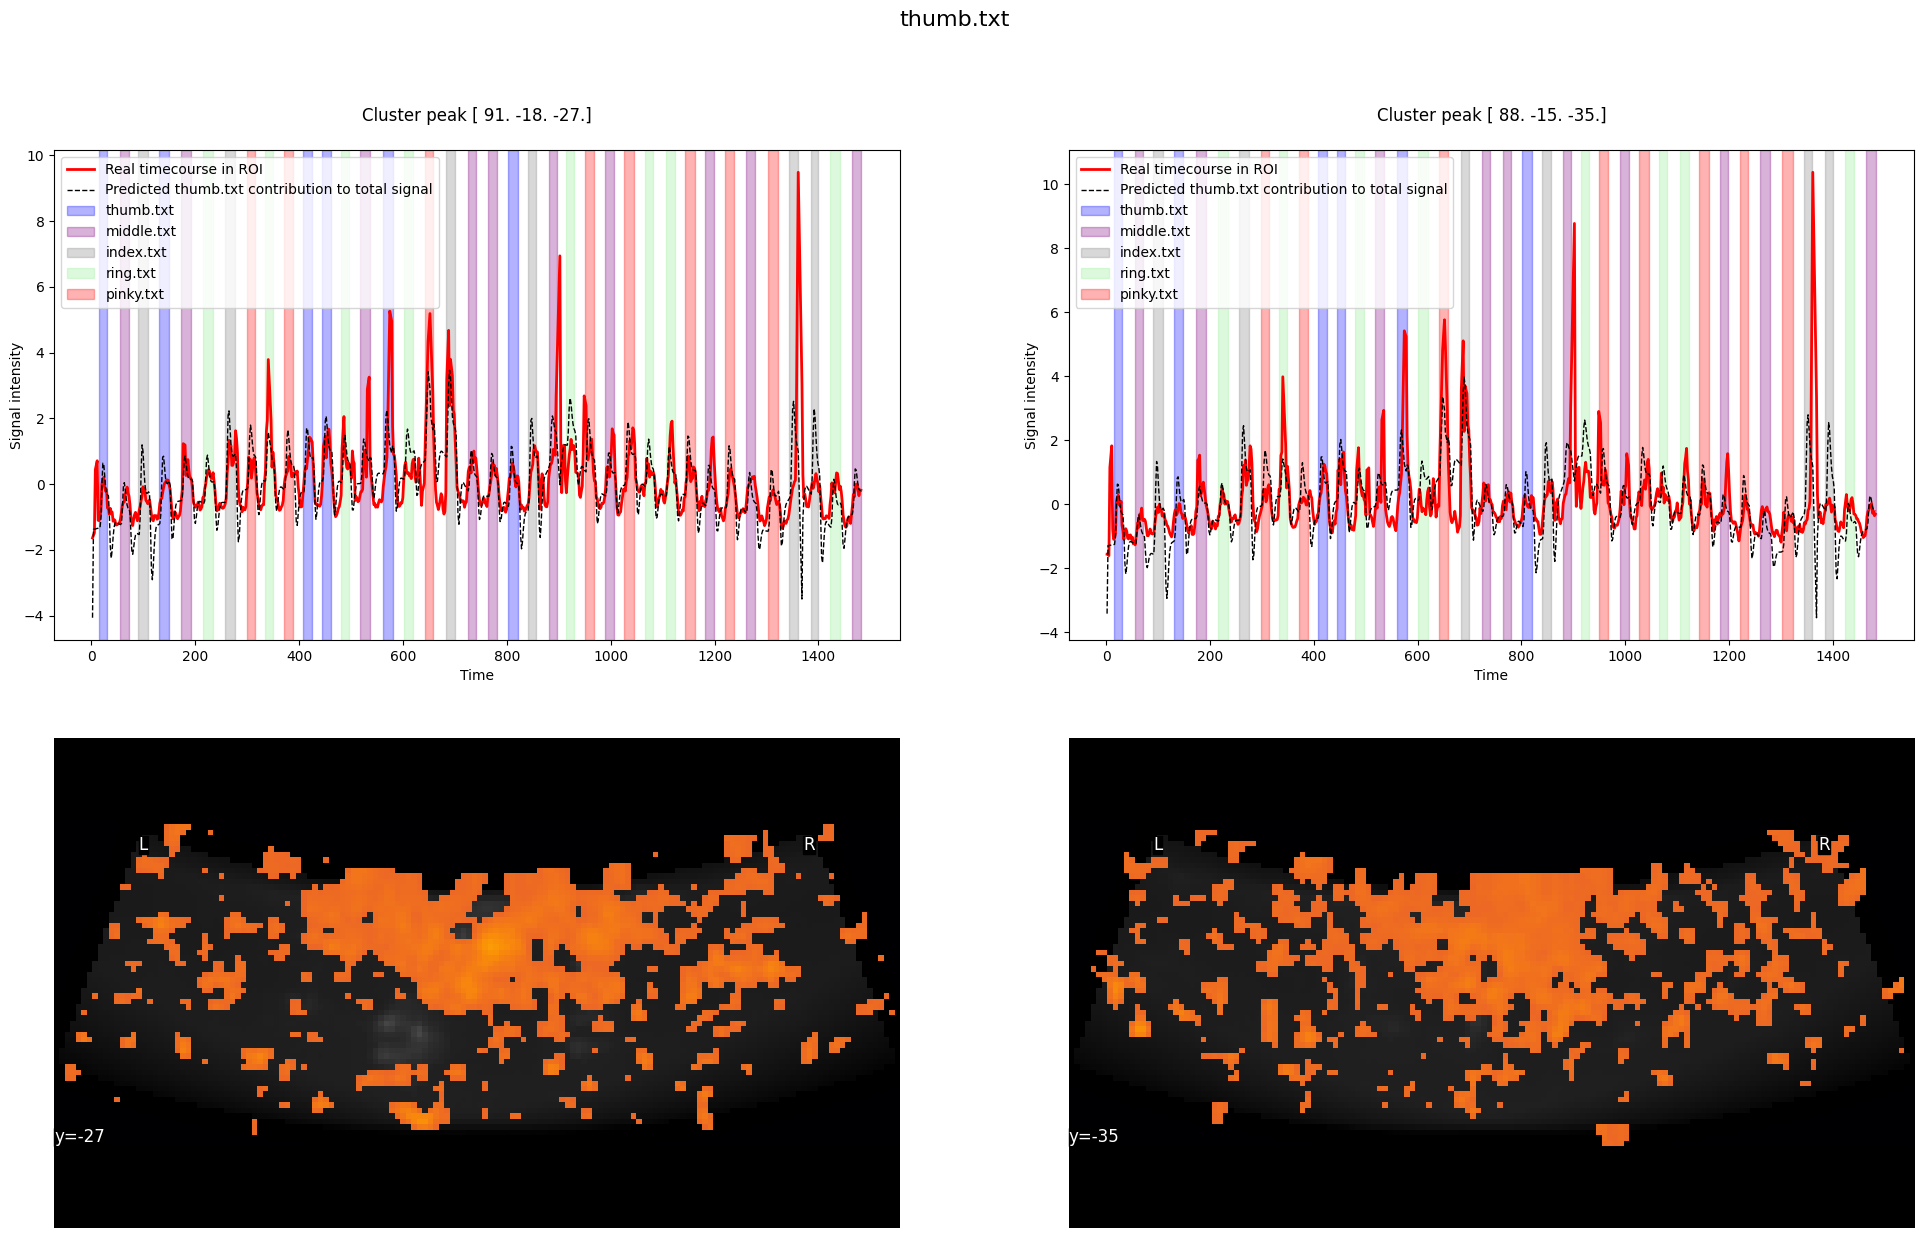

In [24]:
#######################################################################################
#  Extract time series of clusters with z-scores > 3.1 and display their time courses #
#######################################################################################
import pandas as pd
# Create probe events DataFrame with time_stamp column
probe_events = pd.DataFrame(columns=['time_stamp'])
probe_events['time_stamp'] = frame_times


contrast = "thumb.txt"
threshold = 4
roi_radius = 3
[z_map, coords, real_timecourse, predicted_timecourse] = (
    utils.extract_time_course_from_main_clusters(
        contrast,
        threshold,
        sample_masks,
        fusi_img,
        fusi_glm,
        probe_events,
        t_r,
        roi_radius
    )
)
utils.display_real_and_predicted_timecourses(contrast,real_timecourse, predicted_timecourse,task_events, coords, z_map, mean_image)
# utils.display_predicted_timecourses(contrast, predicted_timecourse,task_events, coords, z_map, mean_image)

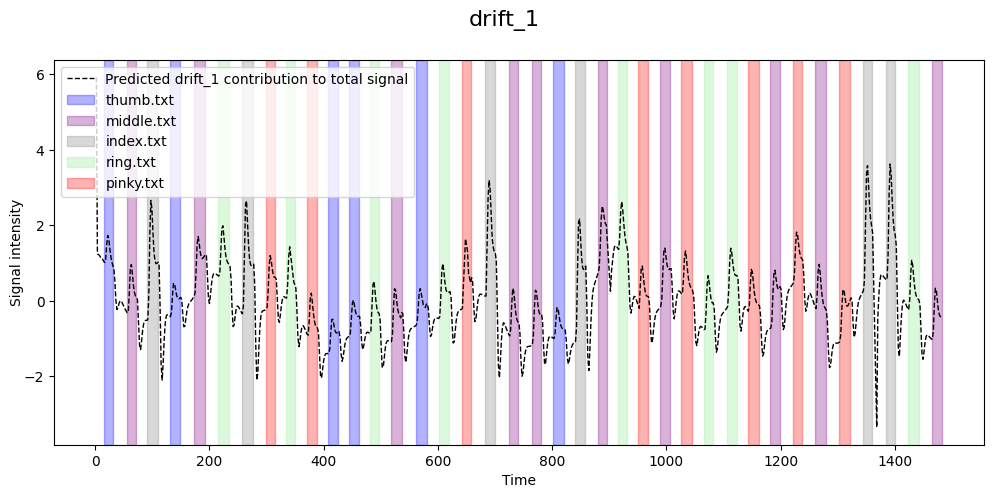

In [25]:
#######################################
#  Extract time series of regressors #
######################################
contrast = "drift_1"

utils.display_regressor_temporal_component(
    contrast,
    fusi_glm=fusi_glm,
    probe_events=probe_events,
    t_r=t_r,
    sample_masks=sample_masks,
    task_events=task_events,
)
